In [1]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import umap
import hdbscan
import matplotlib.pyplot as plt
import pickle
from tqdm.notebook import tqdm

In [2]:
cur_dir = os.getcwd().split('\\')

if cur_dir[-1] == 'notebooks':
    os.chdir("..")

from utils.data_load_utilities.data_loader import load_model_results
from utils.get_global_const import get_global_const
from utils.get_metrics import get_metrics
from utils.get_ranks import get_ranks_s, get_ranks
from methods.ADoE_method import *
from methods.k_nearest_methods import *
from methods.kmeans_methods import *
from methods.opt_methods import *
from methods.sparce_methods import *
from methods.entrophy_metods import *

from testing_pipeline.testing_pipeline_stats import *

from sklearn.linear_model import LassoCV
from sklearn.feature_selection import mutual_info_regression

from datetime import datetime
import re

import warnings
warnings.simplefilter('ignore')

In [3]:
scores, datasets, models = get_global_const()
scores

Parsing Bakeoff2017 models...

Parsing Bakeoff2021 models...

Parsing Bakeoff2023 models...

Parsing HIVE-COTEV2 models...



{'1NN-DTW':                   folds:         0         1         2         3         4  \
 0                  Adiac  0.603581  0.603581  0.601023  0.606138  0.608696   
 1              ArrowHead  0.702857  0.742857  0.680000  0.708571  0.760000   
 2                   Beef  0.633333  0.533333  0.533333  0.500000  0.566667   
 3              BeetleFly  0.700000  0.800000  0.650000  0.800000  0.650000   
 4            BirdChicken  0.750000  0.850000  0.950000  0.800000  0.950000   
 ..                   ...       ...       ...       ...       ...       ...   
 107  EOGHorizontalSignal  0.441989  0.607735  0.566298  0.569061  0.624309   
 108    EOGVerticalSignal  0.433702  0.511050  0.549724  0.566298  0.563536   
 109                 Rock  0.540000  0.680000  0.660000  0.640000  0.720000   
 110                 Crop  0.710536  0.713631  0.706964  0.708929  0.712321   
 111            Chinatown  0.973761  0.909621  0.953353  0.944606  0.970845   
 
             5         6         7     

In [4]:
tsfresh_features = pd.read_csv(Path('data/datasets_features/tsfresh_important_features.csv'), index_col=0)
# tsfresh_features

In [5]:
# chosen_datasets = tsfresh_features.Name.values
chosen_datasets = sorted(datasets)
chosen_datasets[:5]

['ACSF1', 'Adiac', 'ArrowHead', 'BME', 'Beef']

In [6]:
features = pd.read_csv(Path('data/datasets_features/features.csv'), index_col=0)
features = features.set_index('Name')
features = features.loc[chosen_datasets, :]
features = features.reset_index()
features

,Name,entropy,gini,number_of_classes,size
0,ACSF1,3.321928,0.900000,1.0,200.0
1,Adiac,5.202000,0.972675,1.0,781.0
2,ArrowHead,1.576854,0.662833,1.0,211.0
3,BME,1.584963,0.666667,1.0,180.0
4,Beef,2.321928,0.800000,1.0,60.0
...,...,...,...,...,...
107,Wine,0.999473,0.499635,0.0,111.0
108,WordSynonyms,4.071877,0.909999,1.0,905.0
109,Worms,2.117034,0.734211,1.0,258.0
110,WormsTwoClass,0.982591,0.487981,0.0,258.0


In [7]:
sf = features.drop(columns=['Name']).copy()

In [8]:
scores_aggr = {
    model: model_score[model_score["folds:"].isin(chosen_datasets)].reset_index(drop=True) for model, model_score in scores.items()
}

scores_aggr = {
    model: model_score.set_index("folds:").loc[chosen_datasets, :].reset_index() for model, model_score in scores_aggr.items()
}

scores_aggr = {
    model: model_score[model_score.columns[1:]].mean(axis=1) for model, model_score in scores_aggr.items()
}

scores_aggr = pd.DataFrame(scores_aggr)

scores_aggr

,1NN-DTW,Arsenal,BOSS,CIF,CNN,Catch22,DrCIF,EE,FreshPRINCE,HC1,...,STSF,ShapeDTW,Signatures,TDE,TS-CHIEF,TSF,TSFresh,WEASEL-D,WEASEL,cBOSS
0,0.553667,0.805667,0.752667,0.766667,0.345333,0.795667,0.782667,0.571667,0.800000,0.848000,...,0.773333,0.486000,0.726333,0.804000,0.807000,0.667000,0.790000,0.829000,0.775667,0.775000
1,0.603410,0.769224,0.745695,0.766922,0.387383,0.697187,0.811679,0.657374,0.808355,0.790878,...,0.813384,0.653367,0.700256,0.754902,0.779710,0.715686,0.789770,0.817818,0.793606,0.745780
2,0.722095,0.864762,0.860000,0.823238,0.759810,0.760000,0.828000,0.860381,0.788381,0.877524,...,0.789143,0.856000,0.773333,0.897524,0.881143,0.784190,0.613143,0.885143,0.879429,0.881714
3,0.880889,0.997333,0.852889,0.997333,0.977778,0.895111,0.998889,0.975111,0.999111,0.970222,...,0.999556,0.874222,0.993778,0.920444,0.996444,0.960444,0.997111,0.992444,0.936222,0.769556
4,0.504444,0.751111,0.630000,0.792222,0.667778,0.484444,0.794444,0.515556,0.791111,0.718889,...,0.790000,0.530000,0.632222,0.664444,0.632222,0.677778,0.734444,0.776667,0.718889,0.577778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,0.859259,0.916049,0.891975,0.881481,0.537654,0.708642,0.884568,0.867284,0.896914,0.898148,...,0.880864,0.867901,0.868519,0.888272,0.898148,0.857407,0.497531,0.957407,0.901852,0.869136
108,0.646290,0.756688,0.649530,0.703762,0.561651,0.547597,0.705486,0.775653,0.629101,0.698380,...,0.663845,0.664107,0.598171,0.752978,0.793678,0.643887,0.590961,0.750784,0.672466,0.664002
109,0.574026,0.723377,0.726407,0.696104,0.451082,0.723377,0.749784,0.633333,0.772727,0.735931,...,0.713853,0.493506,0.639394,0.744156,0.768398,0.620346,0.747186,0.717749,0.794372,0.716450
110,0.675325,0.796104,0.812987,0.806926,0.605628,0.790909,0.807792,0.712987,0.793506,0.789610,...,0.773160,0.621645,0.697403,0.812554,0.786147,0.682684,0.692208,0.779221,0.833766,0.813420


In [9]:
prep_features = features.copy()
prep_features = prep_features.drop(columns=['Name'])
prep_features['size'] = np.log(prep_features['size'])
prep_features

,entropy,gini,number_of_classes,size
0,3.321928,0.900000,1.0,5.298317
1,5.202000,0.972675,1.0,6.660575
2,1.576854,0.662833,1.0,5.351858
3,1.584963,0.666667,1.0,5.192957
4,2.321928,0.800000,1.0,4.094345
...,...,...,...,...
107,0.999473,0.499635,0.0,4.709530
108,4.071877,0.909999,1.0,6.807935
109,2.117034,0.734211,1.0,5.552960
110,0.982591,0.487981,0.0,5.552960


In [10]:
prep_tsfresh_features = tsfresh_features.copy()
prep_tsfresh_features = prep_tsfresh_features.drop(columns=['Name'])
prep_tsfresh_features

,value__variance_larger_than_standard_deviation,value__has_duplicate_max,value__has_duplicate_min,value__has_duplicate,value__sum_values,value__abs_energy,value__mean_abs_change,value__mean_change,value__mean_second_derivative_central,value__median,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,0,0,0,1,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,0,1
1,0,0,0,0,0,0,1,1,0,1,...,1,1,1,1,1,1,1,1,0,1
2,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,1,1,0,1,...,0,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,0,0,0,0,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,0,1
105,0,1,0,0,1,1,1,1,1,1,...,1,1,1,0,0,0,0,0,0,1
106,0,0,0,0,1,1,1,1,0,1,...,1,0,1,1,1,1,1,1,0,1
107,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,0,1


In [11]:
nn_clusters = [2, 3, 4, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 109]

In [12]:
chosen_datasets = np.array(chosen_datasets)

In [13]:
ranks = get_ranks_s(chosen_datasets, scores, datasets, return_ranks=True)
ranks_all = get_ranks_s(chosen_datasets, scores, datasets, return_ranks=False)

In [14]:
# 1/0

In [15]:
# ranks

In [16]:
metrics = ['MAE', 'MSE', 'Kendall', 'Spearman', 'Pearson', 'Mutual information', 'Adjusted mutual information', 'Normalized mutual information', 'Cramers V', 'Point-Biserial Correlation', 'Phi Coefficient', 'Bloomquist Beta', 'Rank Correlation Ratio', 'Xi Correlation', 'Distance Correlation', 'Me', 'repr']

In [17]:
def random_ind_metr(data: pd.DataFrame, indexes_list, sample_size: int, test_ind, datasets, iter=100, inner_iter=10):
    
    sum_metrics = None
    
    for i in range(iter):
        
        for _ in range(inner_iter):
        
            data_train = data.loc[indexes_list[i]]
            
            indxs = np.random.choice(data_train.index, sample_size, replace=False)
            
            repr_simple = chosen_datasets[[indxs]].squeeze()
        
            ranks_simple = get_ranks(repr_simple, ranks)
            metr = get_metrics(get_ranks(datasets[test_ind].squeeze(), ranks), ranks_simple)
            
            if sum_metrics is None:
                sum_metrics = metr.copy()
            else:
                for key in sum_metrics:
                    sum_metrics[key] += metr[key]

    averaged_metrics = {key: value / (iter * inner_iter) for key, value in sum_metrics.items()}

    return averaged_metrics
    

In [18]:
targets = np.array(scores_aggr.mean(axis=1))

In [19]:
tsfresh_features_full = pd.read_csv(Path('data/datasets_features/tsfresh_full_features.csv'), index_col=0)
prep_tsfresh_features_full = tsfresh_features_full.copy().set_index("Name").loc[chosen_datasets, :]
prep_tsfresh_features_full = prep_tsfresh_features_full.reset_index().drop(columns=['Name'])
prep_tsfresh_features_full = prep_tsfresh_features_full.dropna(axis=1)
prep_tsfresh_features_full = prep_tsfresh_features_full.drop(columns=prep_tsfresh_features_full.columns[(prep_tsfresh_features_full.abs() > 1e9).any()])
constant_features = [col for col in prep_tsfresh_features_full.columns if prep_tsfresh_features_full[col].nunique() <= 1]
prep_tsfresh_features_full = prep_tsfresh_features_full.drop(columns=constant_features)
prep_tsfresh_features_full

,v__variance_larger_than_standard_deviation,v__has_duplicate_max,v__has_duplicate_min,v__has_duplicate,v__sum_values,v__mean_abs_change,v__mean_change,v__mean_second_derivative_central,v__median,v__mean,...,v__fourier_entropy__bins_3,v__fourier_entropy__bins_5,v__fourier_entropy__bins_10,v__fourier_entropy__bins_100,v__permutation_entropy__dimension_3__tau_1,v__permutation_entropy__dimension_4__tau_1,v__permutation_entropy__dimension_5__tau_1,v__permutation_entropy__dimension_6__tau_1,v__permutation_entropy__dimension_7__tau_1,v__mean_n_absolute_max__number_of_maxima_7
0,0.385,0.010000,0.570000,1.000000,1.397573e-08,1.160304,0.000019,-0.000847,-0.542405,9.572421e-12,...,0.077859,0.173448,0.208679,0.394857,1.418109,1.658544,2.182301,2.678302,3.107743,2.825552
1,0.000,0.002561,0.000000,0.040973,1.595424e-08,0.070771,-0.000006,0.000125,-0.098502,9.064907e-11,...,0.073411,0.168004,0.176986,0.223225,0.879698,1.039076,1.177104,1.299305,1.411905,1.698952
2,0.000,0.142180,0.018957,0.909953,1.318861e-08,0.054496,0.000015,-0.000024,0.078746,5.254427e-11,...,0.083061,0.113604,0.141103,0.245041,1.214883,1.688473,2.082949,2.389370,2.631711,1.885942
3,0.000,0.211111,0.105556,1.000000,2.238065e+01,0.034502,0.000011,0.000012,0.093862,1.748488e-01,...,0.175942,0.224622,0.256778,0.561132,1.668032,2.799389,3.756006,4.259495,4.490649,1.041510
4,0.000,0.000000,0.000000,0.916667,-1.127247e-08,0.037038,-0.003015,0.000002,0.081233,-2.398397e-11,...,0.065581,0.112057,0.184807,0.411851,1.281744,1.912363,2.498251,2.984730,3.366054,2.572998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,0.000,0.000000,0.000000,1.000000,2.101288e-08,0.073393,-0.015458,0.000256,-0.337871,8.979865e-11,...,0.097664,0.101614,0.246662,0.416471,1.007531,1.349472,1.694412,2.046765,2.383959,3.007583
108,0.000,0.000000,0.000000,0.057459,1.124446e-08,0.066198,0.000270,-0.000196,-0.325636,4.164614e-11,...,0.136939,0.187805,0.260067,0.490834,0.905597,1.149245,1.393245,1.635372,1.872081,2.938938
109,0.000,0.100775,0.093023,0.992248,4.282148e-08,0.057811,0.000116,-0.000003,-0.006140,4.757942e-11,...,0.099287,0.138546,0.183107,0.351580,1.506146,2.415932,3.346672,4.137341,4.669882,2.474004
110,0.000,0.100775,0.093023,0.992248,4.282148e-08,0.057811,0.000116,-0.000003,-0.006140,4.757942e-11,...,0.099287,0.138546,0.183107,0.351580,1.506146,2.415932,3.346672,4.137341,4.669882,2.474004


In [20]:
meta_tsfresh = pd.read_csv(Path('data/datasets_features/apriori_meta_tsfresh_probe.csv'), index_col=0).reset_index(drop=True)
meta_tsfresh.head()

,err_stump,err_knn1,err_linear,gap_linear_train_test,err_tree_shallow,diff_err_linear_minus_tree,ratio_err_linear_over_knn,var_err_cv_simple,var_err_boot_simple,var_rank_boot_simple,n_objects,series_len_mean,n_features,objects_per_feature
0,0.933415,0.973118,0.309840,0.344681,0.848938,-0.539098,0.318399,0.000720,0.000575,0.000000,781,176.0,783,0.997446
1,0.398117,0.710742,0.132447,0.093750,0.208306,-0.075858,0.186351,0.002796,0.002534,0.075102,211,251.0,783,0.269476
2,0.650000,0.816667,0.083333,0.166667,0.450000,-0.366667,0.102041,0.015972,0.016851,0.418367,60,470.0,783,0.076628
3,0.125000,0.325000,0.100000,0.083333,0.125000,-0.025000,0.307692,0.015625,0.012882,0.713878,40,512.0,783,0.051086
4,0.100000,0.475000,0.050000,0.083333,0.100000,-0.050000,0.105263,0.010937,0.006567,0.320000,40,512.0,783,0.051086


In [21]:
meta_catch22 = pd.read_csv(Path('data/datasets_features/apriori_meta_catch22_probe.csv'), index_col=0).reset_index(drop=True)
meta_catch22.head()

,err_stump,err_knn1,err_linear,gap_linear_train_test,err_tree_shallow,diff_err_linear_minus_tree,ratio_err_linear_over_knn,var_err_cv_simple,var_err_boot_simple,var_rank_boot_simple,n_objects,series_len_mean,n_features,objects_per_feature
0,0.946211,0.553095,0.361032,0.112618,0.877086,-0.516054,0.652749,0.000972,0.001205,0.000000,781,176.0,22,35.500000
1,0.360354,0.260797,0.232115,0.132334,0.227353,0.004762,0.890021,0.000926,0.003830,0.537143,211,251.0,22,9.590909
2,0.733333,0.316667,0.533333,0.119048,0.700000,-0.166667,1.684211,0.015972,0.014723,0.471837,60,470.0,22,2.727273
3,0.200000,0.225000,0.200000,0.083333,0.175000,0.025000,0.888889,0.004687,0.017453,0.938776,40,512.0,22,1.818182
4,0.100000,0.250000,0.100000,0.166667,0.100000,0.000000,0.400000,0.010937,0.012245,0.855510,40,512.0,22,1.818182


In [22]:
meta_summary = pd.read_csv(Path('data/datasets_features/apriori_meta_summary_probe.csv'), index_col=0).reset_index(drop=True)
meta_summary.head()

,err_stump,err_knn1,err_linear,gap_linear_train_test,err_tree_shallow,diff_err_linear_minus_tree,ratio_err_linear_over_knn,var_err_cv_simple,var_err_boot_simple,var_rank_boot_simple,n_objects,series_len_mean,n_features,objects_per_feature
0,0.937253,0.318847,0.306010,0.040223,0.889874,-0.583864,0.959740,0.000072,0.001541,0.000000,781,176.0,17,45.941176
1,0.407641,0.199003,0.241528,0.059524,0.246290,-0.004762,1.213689,0.001753,0.003029,0.294286,211,251.0,17,12.411765
2,0.800000,0.550000,0.466667,0.365079,0.600000,-0.133333,0.848485,0.018750,0.014732,0.581633,60,470.0,17,3.529412
3,0.150000,0.125000,0.125000,0.166667,0.150000,-0.025000,1.000000,0.026562,0.015918,0.613878,40,512.0,17,2.352941
4,0.075000,0.025000,0.050000,0.083333,0.075000,-0.025000,2.000000,0.004687,0.008571,0.539184,40,512.0,17,2.352941


In [23]:
ranks_aggr = pd.DataFrame(columns=chosen_datasets)

for d in chosen_datasets:
    ranks_aggr[d] = ranks[d].drop(columns=['model']).mean(axis=1)

ranks_aggr.transpose()

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
ACSF1,3.100000,21.366667,12.566667,13.700000,1.000000,19.433333,16.433333,3.933333,20.500000,30.600000,...,14.900000,2.000000,8.766667,20.500000,21.733333,6.000000,17.566667,26.300000,15.300000,15.800000
Adiac,2.000000,16.066667,11.700000,15.733333,1.000000,6.666667,29.066667,3.933333,27.966667,22.133333,...,29.033333,3.600000,6.633333,13.466667,18.333333,8.066667,20.933333,31.133333,22.833333,11.733333
ArrowHead,2.666667,21.166667,20.200000,11.800000,5.600000,4.800000,13.066667,19.200000,7.900000,25.433333,...,7.500000,18.433333,5.800000,29.900000,26.300000,7.000000,2.433333,27.333333,24.433333,25.733333
BME,6.266667,22.666667,5.266667,23.266667,16.966667,7.433333,25.766667,15.366667,30.166667,14.733333,...,25.833333,5.700000,20.433333,10.333333,21.400000,12.966667,21.333333,18.566667,10.900000,1.866667
Beef,3.200000,22.766667,11.600000,27.466667,15.766667,3.166667,28.066667,4.466667,28.166667,20.133333,...,27.466667,4.766667,11.933333,14.166667,10.633333,14.900000,20.700000,25.400000,19.800000,7.966667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wine,13.133333,23.200000,18.900000,16.800000,1.933333,3.166667,16.966667,16.866667,19.100000,20.700000,...,17.633333,14.633333,13.566667,15.833333,19.166667,11.100000,1.266667,30.766667,20.066667,15.200000
WordSynonyms,10.933333,25.466667,11.300000,19.966667,1.933333,1.366667,20.433333,30.833333,8.533333,19.333333,...,14.300000,14.033333,4.700000,25.466667,33.966667,10.466667,3.900000,24.800000,16.100000,13.966667
Worms,3.733333,17.866667,19.100000,13.366667,1.433333,18.966667,24.100000,5.833333,29.166667,21.000000,...,16.700000,1.733333,6.566667,21.900000,27.966667,5.066667,23.533333,16.166667,31.500000,17.066667
WormsTwoClass,4.000000,21.500000,26.500000,25.100000,1.900000,20.566667,24.900000,6.933333,21.566667,20.200000,...,16.266667,2.566667,6.233333,25.900000,19.266667,4.600000,6.100000,17.000000,30.200000,26.866667


In [24]:
ranks_aggr_rounded = ranks_aggr.rank(axis=0)
ranks_aggr_rounded[:5]

,ACSF1,Adiac,ArrowHead,BME,Beef,BeetleFly,BirdChicken,CBF,Car,Chinatown,...,UWaveGestureLibraryAll,UWaveGestureLibraryX,UWaveGestureLibraryY,UWaveGestureLibraryZ,Wafer,Wine,WordSynonyms,Worms,WormsTwoClass,Yoga
0,3.0,2.0,2.0,6.0,3.0,3.0,6.0,24.0,1.0,8.0,...,4.0,2.0,1.0,2.0,2.0,6.0,11.0,3.0,3.0,6.0
1,21.0,16.0,19.0,22.0,22.0,15.0,13.0,32.0,30.0,21.0,...,31.0,29.0,27.0,25.0,14.0,27.0,25.5,16.0,22.0,21.0
2,9.0,11.0,18.0,4.0,9.0,28.0,34.0,34.0,16.0,1.0,...,8.0,5.0,4.0,5.0,15.0,21.0,12.0,18.0,32.0,20.0
3,10.0,15.0,10.0,23.0,31.5,10.0,8.0,17.0,13.0,35.0,...,25.0,24.0,20.0,22.0,19.0,13.0,20.0,10.0,30.0,12.0
4,1.0,1.0,4.0,16.0,14.0,6.0,3.0,2.0,5.0,15.0,...,6.0,3.0,2.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0


In [25]:
tsf = pd.read_csv("data/datasets_features/dataset_level/tsfresh_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])
c22 = pd.read_csv("data/datasets_features/dataset_level/catch22_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])
mr  = pd.read_csv("data/datasets_features/dataset_level/minirocket_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])
sm  = pd.read_csv("data/datasets_features/dataset_level/summary_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])

In [26]:
tsf.head()

,v__variance_larger_than_standard_deviation,v__has_duplicate_max,v__has_duplicate_min,v__has_duplicate,v__sum_values,v__abs_energy,v__mean_abs_change,v__mean_change,v__mean_second_derivative_central,v__median,...,v__fourier_entropy__bins_5,v__fourier_entropy__bins_10,v__fourier_entropy__bins_100,v__permutation_entropy__dimension_3__tau_1,v__permutation_entropy__dimension_4__tau_1,v__permutation_entropy__dimension_5__tau_1,v__permutation_entropy__dimension_6__tau_1,v__permutation_entropy__dimension_7__tau_1,v__query_similarity_count__query_None__threshold_0.0,v__mean_n_absolute_max__number_of_maxima_7
0,0.385,0.010000,0.570000,1.000000,1.397573e-08,1460.000000,1.160304,0.000019,-0.000847,-0.542405,...,0.173448,0.208679,0.394857,1.418109,1.658544,2.182301,2.678302,3.107743,NaN,2.825552
1,0.000,0.002561,0.000000,0.040973,1.595424e-08,175.000000,0.070771,-0.000006,0.000125,-0.098502,...,0.168004,0.176986,0.223225,0.879698,1.039076,1.177104,1.299305,1.411905,NaN,1.698952
2,0.000,0.142180,0.018957,0.909953,1.318861e-08,250.000000,0.054496,0.000015,-0.000024,0.078746,...,0.113604,0.141103,0.245041,1.214883,1.688473,2.082949,2.389370,2.631711,NaN,1.885942
3,0.000,0.211111,0.105556,1.000000,2.238065e+01,56.608056,0.034502,0.000011,0.000012,0.093862,...,0.224622,0.256778,0.561132,1.668032,2.799389,3.756006,4.259495,4.490649,NaN,1.041510
4,0.000,0.000000,0.000000,0.916667,-1.127247e-08,469.000000,0.037038,-0.003015,0.000002,0.081233,...,0.112057,0.184807,0.411851,1.281744,1.912363,2.498251,2.984730,3.366054,NaN,2.572998


In [27]:
lm = pd.read_csv("data/datasets_features/landmarking_raw.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])

In [28]:
tsf = tsf.dropna(axis=1)
tsf = tsf.drop(columns=tsf.columns[(tsf.abs() > 1e9).any()])
constant_features = [col for col in tsf.columns if tsf[col].nunique() <= 1]
tsf = tsf.drop(columns=constant_features)
tsf

,v__variance_larger_than_standard_deviation,v__has_duplicate_max,v__has_duplicate_min,v__has_duplicate,v__sum_values,v__mean_abs_change,v__mean_change,v__mean_second_derivative_central,v__median,v__mean,...,v__fourier_entropy__bins_3,v__fourier_entropy__bins_5,v__fourier_entropy__bins_10,v__fourier_entropy__bins_100,v__permutation_entropy__dimension_3__tau_1,v__permutation_entropy__dimension_4__tau_1,v__permutation_entropy__dimension_5__tau_1,v__permutation_entropy__dimension_6__tau_1,v__permutation_entropy__dimension_7__tau_1,v__mean_n_absolute_max__number_of_maxima_7
0,0.385,0.010000,0.570000,1.000000,1.397573e-08,1.160304,0.000019,-0.000847,-0.542405,9.572421e-12,...,0.077859,0.173448,0.208679,0.394857,1.418109,1.658544,2.182301,2.678302,3.107743,2.825552
1,0.000,0.002561,0.000000,0.040973,1.595424e-08,0.070771,-0.000006,0.000125,-0.098502,9.064907e-11,...,0.073411,0.168004,0.176986,0.223225,0.879698,1.039076,1.177104,1.299305,1.411905,1.698952
2,0.000,0.142180,0.018957,0.909953,1.318861e-08,0.054496,0.000015,-0.000024,0.078746,5.254427e-11,...,0.083061,0.113604,0.141103,0.245041,1.214883,1.688473,2.082949,2.389370,2.631711,1.885942
3,0.000,0.211111,0.105556,1.000000,2.238065e+01,0.034502,0.000011,0.000012,0.093862,1.748488e-01,...,0.175942,0.224622,0.256778,0.561132,1.668032,2.799389,3.756006,4.259495,4.490649,1.041510
4,0.000,0.000000,0.000000,0.916667,-1.127247e-08,0.037038,-0.003015,0.000002,0.081233,-2.398397e-11,...,0.065581,0.112057,0.184807,0.411851,1.281744,1.912363,2.498251,2.984730,3.366054,2.572998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,0.000,0.000000,0.000000,1.000000,2.101288e-08,0.073393,-0.015458,0.000256,-0.337871,8.979865e-11,...,0.097664,0.101614,0.246662,0.416471,1.007531,1.349472,1.694412,2.046765,2.383959,3.007583
108,0.000,0.000000,0.000000,0.057459,1.124446e-08,0.066198,0.000270,-0.000196,-0.325636,4.164614e-11,...,0.136939,0.187805,0.260067,0.490834,0.905597,1.149245,1.393245,1.635372,1.872081,2.938938
109,0.000,0.100775,0.093023,0.992248,4.282148e-08,0.057811,0.000116,-0.000003,-0.006140,4.757942e-11,...,0.099287,0.138546,0.183107,0.351580,1.506146,2.415932,3.346672,4.137341,4.669882,2.474004
110,0.000,0.100775,0.093023,0.992248,4.282148e-08,0.057811,0.000116,-0.000003,-0.006140,4.757942e-11,...,0.099287,0.138546,0.183107,0.351580,1.506146,2.415932,3.346672,4.137341,4.669882,2.474004


In [29]:
tsf.isna().values.any()

False

In [30]:
def a_optimality_ind(data,
                     sample_size: int,
                     model_list=None,
                     scale_data: bool = True,
                     iter: int = 100,
                     alpha: float = 1e-4,
                     random_state: int = 42,
                     pca_099 = False,
                     **kwargs):

    X = np.asarray(data)
    
    if pca_099:
        X = np.array(StandardScaler().fit_transform(X))
        X = PCA(0.99).fit_transform(X) 

    if scale_data:
        X = StandardScaler().fit_transform(X)

    df = pd.DataFrame(X)
    
    return a_d_optimality_ind(df,
                              sample_size=sample_size,
                              optimality='a',
                              iter=iter,
                              alpha=alpha,
                              random_state=random_state,
                              return_ind=True)


def d_optimality_ind(data,
                     sample_size: int,
                     model_list=None,
                     scale_data: bool = True,
                     iter: int = 100,
                     alpha: float = 1e-4,
                     random_state: int = 42,
                     pca_099 = False,
                     **kwargs):

    X = np.asarray(data)
    
    if pca_099:
        X = np.array(StandardScaler().fit_transform(X))
        X = PCA(0.99).fit_transform(X) 

    if scale_data:
        X = StandardScaler().fit_transform(X)

    df = pd.DataFrame(X)
    return a_d_optimality_ind(df,
                              sample_size=sample_size,
                              optimality='d',
                              iter=iter,
                              alpha=alpha,
                              random_state=random_state,
                              return_ind=True)

In [31]:
metods_data_list = [
    [rand_ind_method, c22.values,
     range(2, 21),
     False, False,
     {"random_state": 42},
     False, False,
     'Random_112_200_MODELS_42'],
    
    [get_more_different_datasets,
    c22.values,
    range(2, 21),
    False,
    False,
    {'scale_data': True},
    False,
    False,
    'Cosine_Method_Catch22_112_200_MODELS'],
    
    [k_means_ind,
    lm.values,
    range(2, 21),
    False,
    False,
    {'scale_data': True},
    False,
    False,
    'K-Means_TSFRESH_112_200_MODELS'],
    
    [get_more_different_datasets_euclid,
    sm.values,
    range(2, 21),
    False,
    False,
    {'scale_data': True},
    False,
    False,
    'EuclidMethod_MiniRocket_112_200_MODELS'],
    
    [a_optimality_ind, lm.values,
     range(2, 21),
     False, False,
     {'scale_data': True, 'iter': 1, 'alpha': 1e-4, 'random_state': 42},
     False, False,
     'A-opt_Landmarking_112_200_MODELS'],

    [d_optimality_ind, lm.values,
     range(2, 21),
     False, False,
     {'scale_data': True, 'iter': 1, 'alpha': 1e-4, 'random_state': 42},
     False, False,
     'D-opt_Landmarking_112_200_MODELS'],  
]

Calculating Ranks:   0%|          | 0/200 [00:00<?, ?it/s]

Random_112_200_MODELS_42:   0%|          | 0/19 [00:00<?, ?it/s]

Loading Cosine_Method_Catch22_112_200_MODELS results...
Loading K-Means_TSFRESH_112_200_MODELS results...
Loading EuclidMethod_MiniRocket_112_200_MODELS results...
Loading A-opt_Landmarking_112_200_MODELS results...
Loading D-opt_Landmarking_112_200_MODELS results...
Random_112_200_MODELS_42  | MAE      | AUC(mean)=16.09, AUC(std)=0.89, AUC(q2.5)=12.0669, AUC(q97.5)=20.2549, delta=8.1880
Cosine_Method_Catch22_112_200_MODELS | MAE      | AUC(mean)=14.75, AUC(std)=1.47, AUC(q2.5)=11.3016, AUC(q97.5)=18.6892, delta=7.3876
K-Means_TSFRESH_112_200_MODELS | MAE      | AUC(mean)=14.13, AUC(std)=0.97, AUC(q2.5)=10.4477, AUC(q97.5)=17.7332, delta=7.2854
EuclidMethod_MiniRocket_112_200_MODELS | MAE      | AUC(mean)=13.09, AUC(std)=1.36, AUC(q2.5)=9.1595, AUC(q97.5)=16.8500, delta=7.6905
A-opt_Landmarking_112_200_MODELS | MAE      | AUC(mean)=13.68, AUC(std)=1.11, AUC(q2.5)=10.0820, AUC(q97.5)=17.5330, delta=7.4510
D-opt_Landmarking_112_200_MODELS | MAE      | AUC(mean)=14.35, AUC(std)=1.30, AUC(

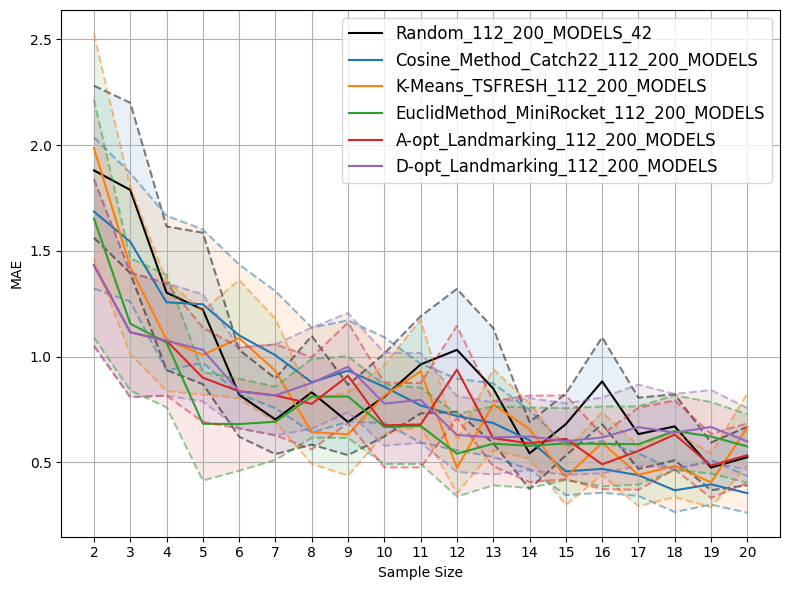

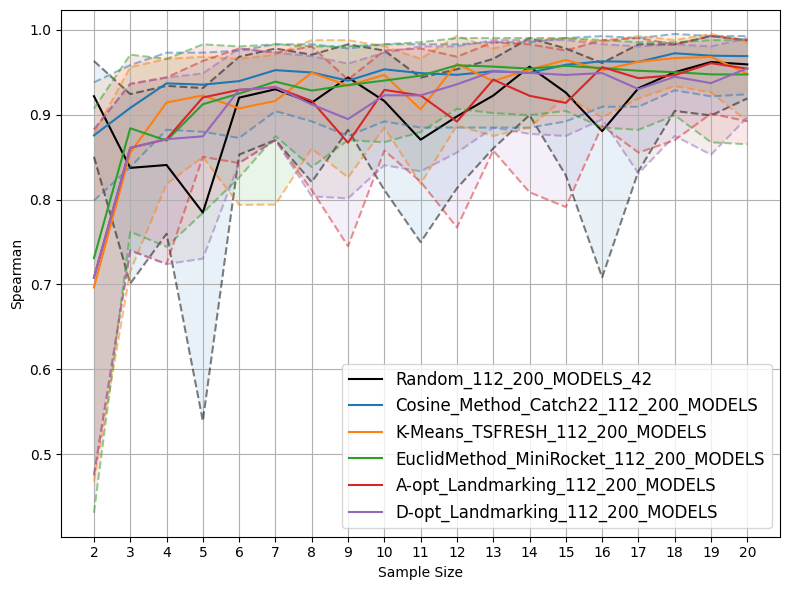

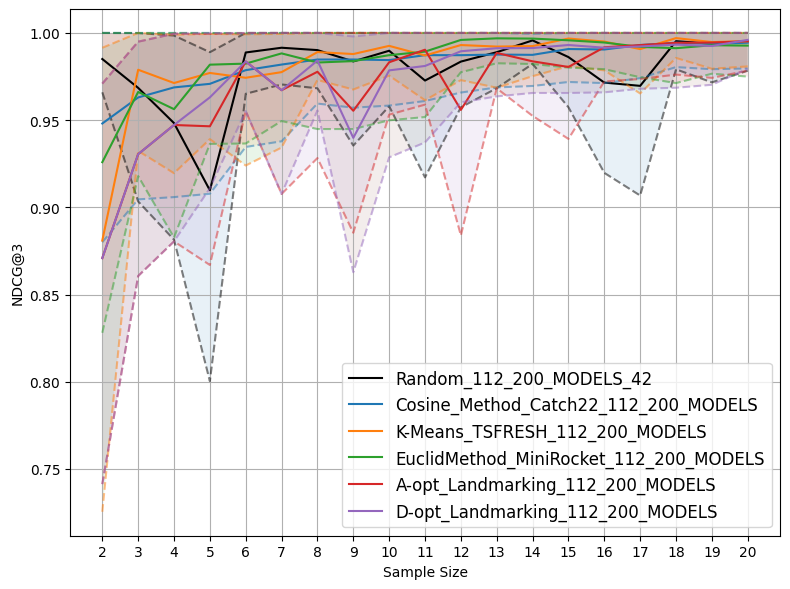

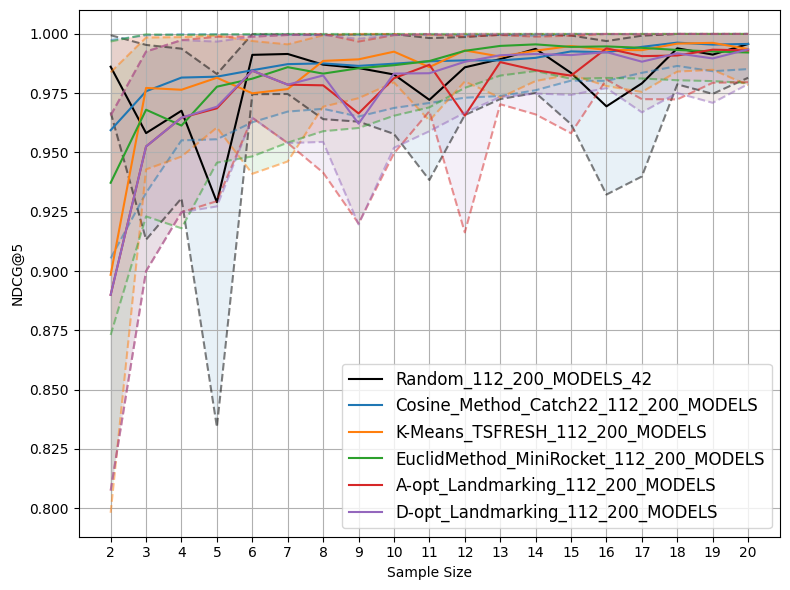

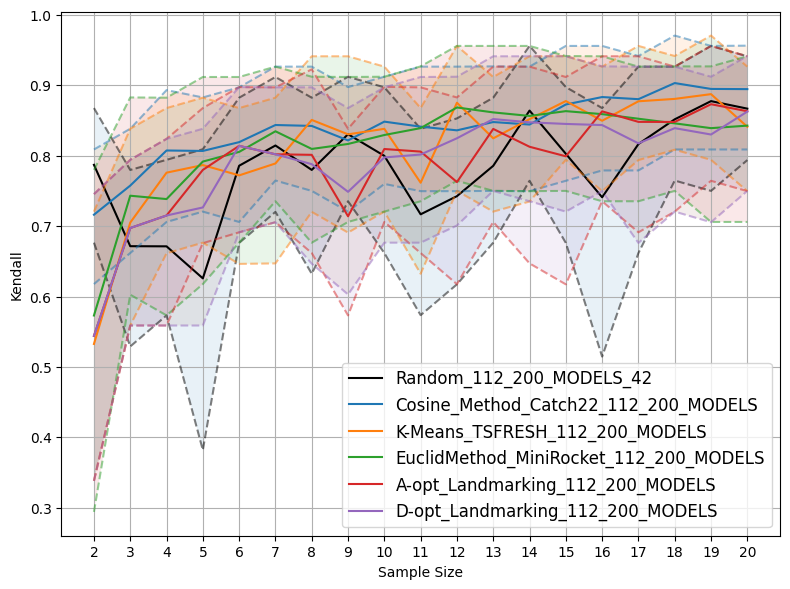

<Figure size 800x600 with 0 Axes>

In [32]:
testing_pipeline(chosen_datasets, metods_data_list, ranks, scores, chosen_datasets, ratio=0.5, models_prefix='',
                 load_res=True, save_results=True, save_checpoints=True, num_models=35, models_bench=True, test_iter=200, load_ranks=False)

In [33]:
1/0

ZeroDivisionError: division by zero

In [ ]:
data_rec = pd.read_csv(Path('data/rec_sys_datasets/Datafeatures_and_metrics.csv')).sort_values(by='Dataset')

In [ ]:
datasets_recsys = data_rec['Dataset'].unique()
datasets_recsys, datasets_recsys.shape

(array(['amazon_cds', 'amazon_finefoods', 'amazon_mi', 'amazon_tv',
        'beeradvocate', 'brightkite', 'dianping', 'douban_books',
        'douban_movies', 'douban_music', 'epinions', 'food', 'foursquare',
        'goodreads', 'gowalla', 'kuairec_full', 'kuairec_small',
        'movielens_10m', 'movielens_1m', 'movielens_20m', 'mts_library',
        'netflix', 'ratebeer', 'reddit', 'rekko', 'retail', 'sber_smm',
        'sber_zvuk', 'tafeng', 'yelp'], dtype=object),
 (30,))

In [ ]:
temp = data_rec.groupby(["Method", "Dataset"])["Value"].mean().unstack("Dataset")
# temp = metrics_data.groupby(["Method", "Dataset"])["Value"].mean().unstack("Dataset")
ranks_aggr_recsys = temp.rank(method="min", ascending=False)
ranks_aggr_recsys.index.name = None
ranks_aggr_recsys.columns.name = None
# ranks_aggr_recsys = ranks_aggr_recsys.reset_index(drop=True)
ranks_aggr_recsys = ranks_aggr_recsys
ranks_aggr_recsys

,amazon_cds,amazon_finefoods,amazon_mi,amazon_tv,beeradvocate,brightkite,dianping,douban_books,douban_movies,douban_music,...,mts_library,netflix,ratebeer,reddit,rekko,retail,sber_smm,sber_zvuk,tafeng,yelp
ALS,5.0,1.0,5.0,5.0,1.0,8.0,7.0,6.0,6.0,6.0,...,5.0,5.0,4.0,7.0,2.0,7.0,4.0,3.0,7.0,3.0
BPR,8.0,9.0,7.0,8.0,9.0,9.0,9.0,1.0,2.0,4.0,...,9.0,8.0,8.0,9.0,9.0,8.0,9.0,9.0,1.0,8.0
EASE,2.0,2.0,4.0,2.0,2.0,1.0,2.0,4.0,4.0,9.0,...,1.0,1.0,3.0,2.0,1.0,1.0,2.0,1.0,6.0,1.0
ItemKNN,6.0,8.0,2.0,6.0,4.0,7.0,5.0,8.0,7.0,7.0,...,4.0,9.0,5.0,6.0,7.0,5.0,3.0,5.0,5.0,7.0
LightFM,7.0,7.0,8.0,7.0,6.0,6.0,6.0,5.0,8.0,8.0,...,3.0,3.0,6.0,8.0,3.0,9.0,6.0,4.0,2.0,6.0
LightGCL,1.0,5.0,1.0,4.0,8.0,5.0,8.0,9.0,9.0,3.0,...,8.0,6.0,9.0,4.0,8.0,6.0,7.0,8.0,4.0,5.0
LightGCN,4.0,3.0,3.0,1.0,7.0,3.0,4.0,7.0,1.0,1.0,...,6.0,4.0,2.0,3.0,6.0,3.0,8.0,6.0,9.0,4.0
MultiVAE,3.0,6.0,6.0,3.0,5.0,4.0,3.0,2.0,5.0,5.0,...,7.0,2.0,7.0,1.0,5.0,4.0,5.0,2.0,3.0,2.0
SLIM,9.0,4.0,9.0,9.0,3.0,2.0,1.0,3.0,3.0,2.0,...,2.0,7.0,1.0,5.0,4.0,2.0,1.0,7.0,8.0,9.0


In [ ]:
ranks_recsys = {}
for ds in datasets_recsys:
    df_ds = pd.DataFrame({
        "model": ranks_aggr_recsys.index,
    })
    for i in range(30):
        df_ds[str(i)] = ranks_aggr_recsys[ds].values
    ranks_recsys[ds] = df_ds
ranks_recsys

{'amazon_cds':       model    0    1    2    3    4    5    6    7    8  ...   20   21   22  \
 0       ALS  5.0  5.0  5.0  5.0  5.0  5.0  5.0  5.0  5.0  ...  5.0  5.0  5.0   
 1       BPR  8.0  8.0  8.0  8.0  8.0  8.0  8.0  8.0  8.0  ...  8.0  8.0  8.0   
 2      EASE  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  ...  2.0  2.0  2.0   
 3   ItemKNN  6.0  6.0  6.0  6.0  6.0  6.0  6.0  6.0  6.0  ...  6.0  6.0  6.0   
 4   LightFM  7.0  7.0  7.0  7.0  7.0  7.0  7.0  7.0  7.0  ...  7.0  7.0  7.0   
 5  LightGCL  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  ...  1.0  1.0  1.0   
 6  LightGCN  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  ...  4.0  4.0  4.0   
 7  MultiVAE  3.0  3.0  3.0  3.0  3.0  3.0  3.0  3.0  3.0  ...  3.0  3.0  3.0   
 8      SLIM  9.0  9.0  9.0  9.0  9.0  9.0  9.0  9.0  9.0  ...  9.0  9.0  9.0   
 
     23   24   25   26   27   28   29  
 0  5.0  5.0  5.0  5.0  5.0  5.0  5.0  
 1  8.0  8.0  8.0  8.0  8.0  8.0  8.0  
 2  2.0  2.0  2.0  2.0  2.0  2.0  2.0  
 3  6.0  6.0  

In [ ]:
recsys_features = (data_rec.drop(columns=['Method', 'Value']).drop_duplicates(subset=['Dataset'])
                   .sort_values(by='Dataset').reset_index(drop=True))
recsys_features.head()

,Dataset,Nu,Ni,Nr,SpaceSize,Shape,Density,Rpu,Rpi,Ginii,Giniu,APB,StPB,SkPB,KuPB,LTavg,LTstd,LTsk,LTku
0,amazon_cds,69394,116073,1178506,8054769762,0.597848,0.000146,16.982823,10.153145,0.488385,0.517409,0.001067,0.001119,2.485566,8.821879,0.218731,0.159860,0.868915,1.073294
1,amazon_finefoods,14710,12916,139682,189994360,1.138897,0.000735,9.495717,10.814648,0.745315,0.303484,0.006071,0.005895,1.676080,3.215419,0.195233,0.290444,1.562988,1.353715
2,amazon_mi,9785,28921,189312,282991985,0.338335,0.000669,19.347164,6.545832,0.321962,0.566611,0.001109,0.000562,3.289954,17.372120,0.232518,0.157825,0.842145,1.147264
3,amazon_tv,49940,215640,2272799,10769061600,0.231590,0.000211,45.510593,10.539784,0.407253,0.700633,0.001142,0.001114,2.718885,11.026001,0.189440,0.135193,1.083515,2.443856
4,beeradvocate,12689,18209,1162277,231054001,0.696853,0.005030,91.597210,63.829809,0.747503,0.734290,0.050772,0.021663,0.726604,0.984521,0.152547,0.147474,1.594852,3.639196


In [ ]:
scores_aggr_recsys = data_rec.sort_values(by='Dataset').pivot(index='Dataset', columns='Method', values='Value').reset_index()
scores_aggr_recsys = scores_aggr_recsys.set_index('Dataset').reindex(recsys_features['Dataset']).reset_index()
scores_aggr_recsys = scores_aggr_recsys.drop(columns=['Dataset'])
recsys_features = recsys_features.drop(columns=['Dataset'])
scores_aggr_recsys.columns.name = None
scores_aggr_recsys

,ALS,BPR,EASE,ItemKNN,LightFM,LightGCL,LightGCN,MultiVAE,SLIM
0,0.010767,0.005982,0.012446,0.008170,0.007969,0.012803,0.011495,0.011518,0.003841
1,0.032295,0.015093,0.029496,0.018599,0.020408,0.022279,0.029227,0.022171,0.023494
2,0.003348,0.002463,0.003457,0.003612,0.002330,0.004419,0.003498,0.002846,0.001067
3,0.009324,0.003192,0.012212,0.006780,0.005838,0.009756,0.013763,0.010012,0.000305
4,0.075577,0.060444,0.074374,0.070596,0.068811,0.066276,0.067470,0.069462,0.072609
5,0.064451,0.056549,0.127679,0.083596,0.104574,0.105272,0.120321,0.107733,0.126039
6,0.019675,0.014003,0.022301,0.021041,0.019737,0.018616,0.021342,0.021826,0.022698
7,0.018610,0.021935,0.019104,0.018009,0.019010,0.014797,0.018224,0.020590,0.019992
8,0.021919,0.022657,0.022195,0.021796,0.019838,0.018281,0.023273,0.022157,0.022437
9,0.017312,0.019401,0.015962,0.016992,0.016191,0.020769,0.026594,0.017602,0.025031


In [ ]:
models_recsys = scores_aggr_recsys.keys()
models_recsys

Index(['ALS', 'BPR', 'EASE', 'ItemKNN', 'LightFM', 'LightGCL', 'LightGCN',
       'MultiVAE', 'SLIM'],
      dtype='object')

In [ ]:
scores_recsys = {}
for model in models_recsys:
    df_ds = pd.DataFrame({
        "folds:": ranks_aggr_recsys.columns,
    })
    for i in range(30):
        df_ds[str(i)] = scores_aggr_recsys[model].values
    scores_recsys[model] = df_ds
scores_recsys

{'ALS':               folds:         0         1         2         3         4  \
 0         amazon_cds  0.010767  0.010767  0.010767  0.010767  0.010767   
 1   amazon_finefoods  0.032295  0.032295  0.032295  0.032295  0.032295   
 2          amazon_mi  0.003348  0.003348  0.003348  0.003348  0.003348   
 3          amazon_tv  0.009324  0.009324  0.009324  0.009324  0.009324   
 4       beeradvocate  0.075577  0.075577  0.075577  0.075577  0.075577   
 5         brightkite  0.064451  0.064451  0.064451  0.064451  0.064451   
 6           dianping  0.019675  0.019675  0.019675  0.019675  0.019675   
 7       douban_books  0.018610  0.018610  0.018610  0.018610  0.018610   
 8      douban_movies  0.021919  0.021919  0.021919  0.021919  0.021919   
 9       douban_music  0.017312  0.017312  0.017312  0.017312  0.017312   
 10          epinions  0.013248  0.013248  0.013248  0.013248  0.013248   
 11              food  0.017816  0.017816  0.017816  0.017816  0.017816   
 12        foursqu

In [ ]:
metods_data_list = [
                    [rand_ind_method, recsys_features.values,
                     range(2, 21),
                     False,
                     False,
                     {"random_state": 42}, 
                     False,
                     False,
                     'Random_RecSys_50_MODELS_42'],
                    # [get_more_different_datasets,
                    #  meta_tsfresh.values,
                    #  range(2, 21),
                    #  False,
                    #  False,
                    #  {'scale_data': True},
                    #  False,
                    #  False,
                    #  'Cosine_Method_SF_TEST_D4'],
                    [get_more_different_datasets,
                     recsys_features.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': True},
                     False,
                     False, 
                     'Cosine_Method_RecSys_50_MODELS'],
                    [k_means_ind,
                     recsys_features.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': True},
                     False,
                     False, 
                     'K-Means_RecSys_50_MODELS'],
                    [get_more_different_datasets_euclid,
                     recsys_features.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': True},
                     False,
                     False, 
                     'EuclidMethod_RecSys_50_MODELS'],
                    [a_optimality_ind,
                     recsys_features.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': True, 'iter': 5, 'alpha': 1e-4, 'random_state': 42},
                     False,
                     False, 
                     'A-opt_RecSys_50_MODELS'],
                    [d_optimality_ind,
                     recsys_features.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': True, 'iter': 5, 'alpha': 1e-4, 'random_state': 42},
                     False,
                     False, 
                     'D-opt_RecSys_50_MODELS'],
                    ]


In [ ]:
datasets_recsys

array(['amazon_cds', 'amazon_finefoods', 'amazon_mi', 'amazon_tv',
       'beeradvocate', 'brightkite', 'dianping', 'douban_books',
       'douban_movies', 'douban_music', 'epinions', 'food', 'foursquare',
       'goodreads', 'gowalla', 'kuairec_full', 'kuairec_small',
       'movielens_10m', 'movielens_1m', 'movielens_20m', 'mts_library',
       'netflix', 'ratebeer', 'reddit', 'rekko', 'retail', 'sber_smm',
       'sber_zvuk', 'tafeng', 'yelp'], dtype=object)

In [ ]:
ranks_recsys.keys()

dict_keys(['amazon_cds', 'amazon_finefoods', 'amazon_mi', 'amazon_tv', 'beeradvocate', 'brightkite', 'dianping', 'douban_books', 'douban_movies', 'douban_music', 'epinions', 'food', 'foursquare', 'goodreads', 'gowalla', 'kuairec_full', 'kuairec_small', 'movielens_10m', 'movielens_1m', 'movielens_20m', 'mts_library', 'netflix', 'ratebeer', 'reddit', 'rekko', 'retail', 'sber_smm', 'sber_zvuk', 'tafeng', 'yelp'])

In [ ]:
scores_recsys.keys()

dict_keys(['ALS', 'BPR', 'EASE', 'ItemKNN', 'LightFM', 'LightGCL', 'LightGCN', 'MultiVAE', 'SLIM'])

In [ ]:
scores_recsys['ALS'].keys()

Index(['folds:', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29'],
      dtype='object')

Calculating Ranks:   0%|          | 0/50 [00:00<?, ?it/s]

Random_RecSys_50_MODELS_42:   0%|          | 0/19 [00:00<?, ?it/s]

Loading Cosine_Method_RecSys_50_MODELS results...
Loading K-Means_RecSys_50_MODELS results...
Loading EuclidMethod_RecSys_50_MODELS results...
Loading A-opt_RecSys_50_MODELS results...
Loading D-opt_RecSys_50_MODELS results...
Random_RecSys_50_MODELS_42 | MAE      | AUC(mean)=5.29, AUC(std)=0.33, AUC(q2.5)=3.0924, AUC(q97.5)=7.5944, delta=4.5020
Cosine_Method_RecSys_50_MODELS | MAE      | AUC(mean)=4.61, AUC(std)=0.72, AUC(q2.5)=2.4394, AUC(q97.5)=6.8126, delta=4.3731
K-Means_RecSys_50_MODELS  | MAE      | AUC(mean)=4.50, AUC(std)=0.42, AUC(q2.5)=2.3804, AUC(q97.5)=6.7300, delta=4.3496
EuclidMethod_RecSys_50_MODELS | MAE      | AUC(mean)=5.31, AUC(std)=0.76, AUC(q2.5)=2.8463, AUC(q97.5)=7.4690, delta=4.6227
A-opt_RecSys_50_MODELS    | MAE      | AUC(mean)=4.94, AUC(std)=0.71, AUC(q2.5)=2.5972, AUC(q97.5)=7.3020, delta=4.7048
D-opt_RecSys_50_MODELS    | MAE      | AUC(mean)=4.70, AUC(std)=0.64, AUC(q2.5)=2.5516, AUC(q97.5)=6.9912, delta=4.4395
Random_RecSys_50_MODELS_42 | Spearman | AUC

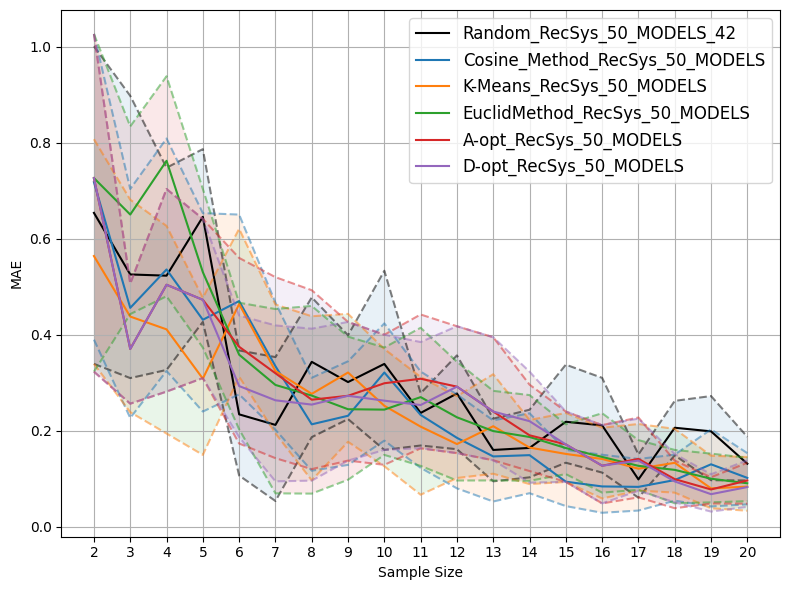

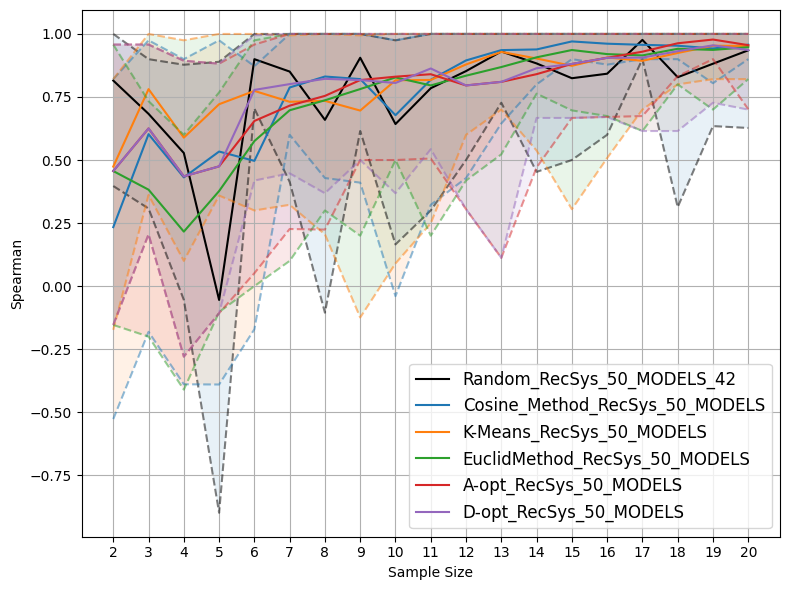

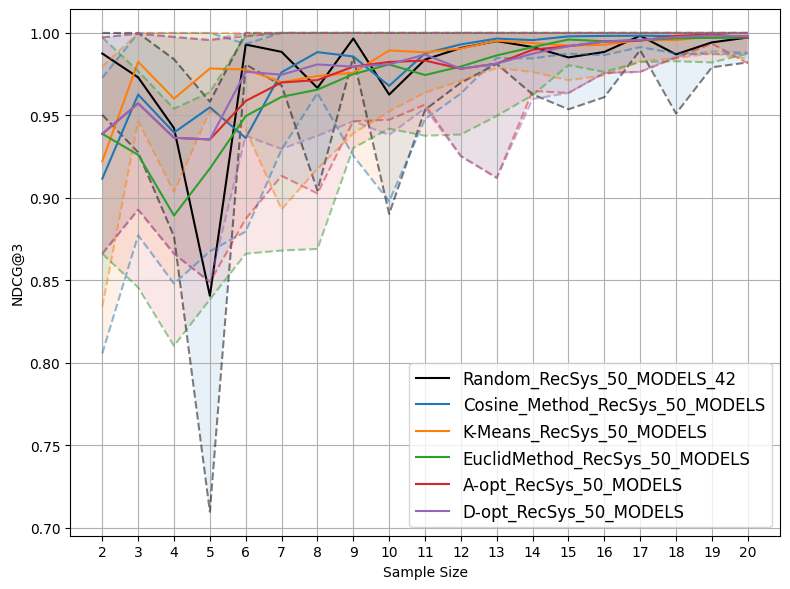

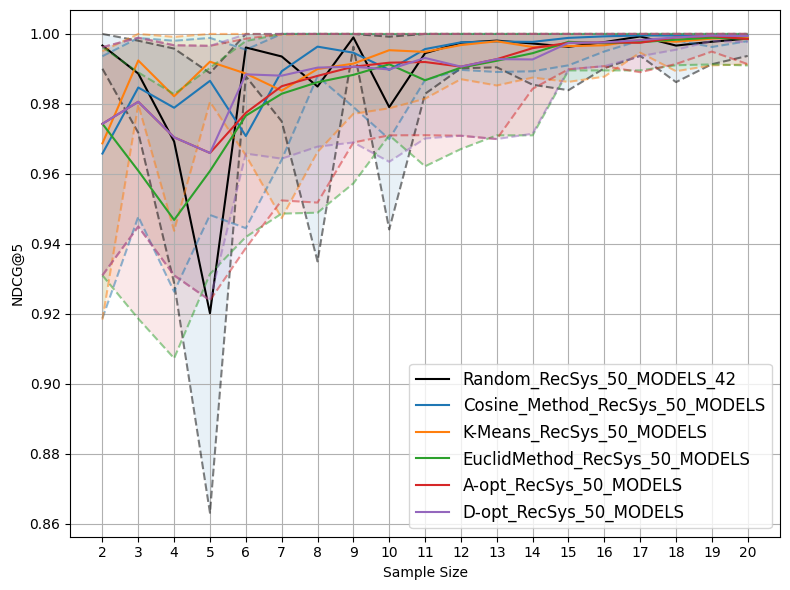

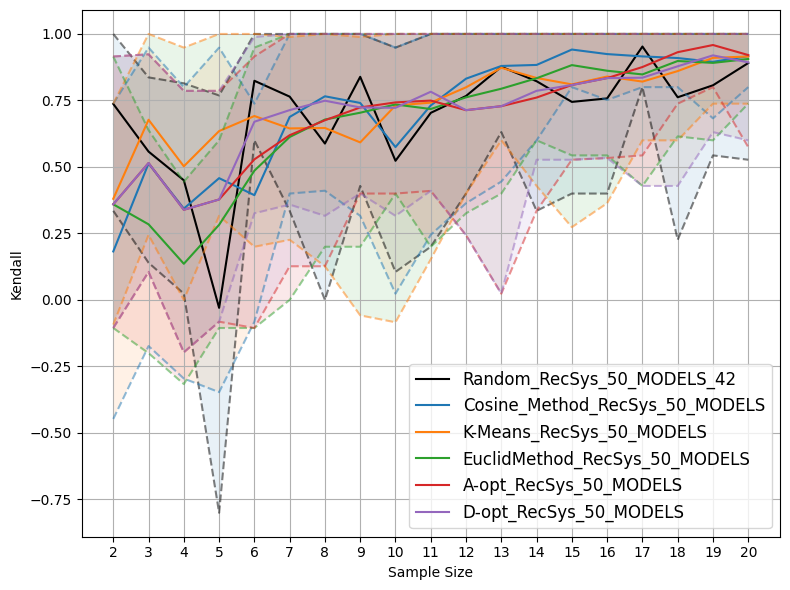

<Figure size 800x600 with 0 Axes>

In [ ]:
testing_pipeline(datasets_recsys, metods_data_list, ranks_recsys, scores_recsys, datasets_recsys, ratio=0.6, models_prefix='',
                 load_res=True, save_results=True, save_checpoints=True, num_models=9, test_iter=50, models_bench=True, load_ranks=False)